# TriWeb ML opérationnel — Retards, Surcharge et Score d'affectation

Notebook corrigé avec :

1. **Prédiction des retards** avec raisonnement métier + comparaison de **3 modèles ML**.
2. **Estimation de surcharge / charge future** avec comparaison de **3 modèles de régression**.
3. **Score d'affectation** basé sur `etatR`, `etatG`, `teamR`, `teamG`, `team`, avec comparaison de **3 modèles de classification**.
4. Visualisations claires : distributions, comparaisons de modèles, matrices de confusion, importance des variables, top dossiers à risque.
5. Export des CSV compatibles avec `main.py` :

```text
models/prediction_retards_resultats.csv
models/prediction_charge_future.csv
models/score_affectation_resultats.csv
models/score_affectation_top5.csv
models/triweb_clean_ml_dataset.csv
```

> Principe : Angular et .NET affichent seulement les résultats. Le raisonnement métier et les scores sont corrigés ici, côté Python/ML.

## 0. Installation optionnelle

Décommente la cellule suivante seulement si une librairie manque dans ton environnement.

In [22]:
# !pip install pandas numpy requests scikit-learn matplotlib openpyxl

## 1. Imports et configuration

In [23]:
import os
import re
import json
import math
import unicodedata
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import urllib3
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
)

warnings.filterwarnings("ignore")
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

API_URL = os.getenv(
    "TRIWEB_API_URL",
    "https://tools.triweb-apps.com/Triweb_NewV/intern/api/VDbPlanificationMaj"
)
API_TOKEN = os.getenv("TRIWEB_API_TOKEN", "")

REFERENCE_DATE = pd.Timestamp.today().normalize()
CAPACITE_JOUR_MINUTES = 480
RANDOM_STATE = 42

OUTPUT_RAW = MODELS_DIR / "triweb_raw_api.csv"
OUTPUT_CLEAN = MODELS_DIR / "triweb_clean_ml_dataset.csv"
OUTPUT_RETARD_RESULTS = MODELS_DIR / "prediction_retards_resultats.csv"
OUTPUT_CHARGE_RESULTS = MODELS_DIR / "prediction_charge_future.csv"
OUTPUT_SCORE_FULL = MODELS_DIR / "score_affectation_resultats.csv"
OUTPUT_SCORE_TOP5 = MODELS_DIR / "score_affectation_top5.csv"

print("BASE_DIR:", BASE_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("REFERENCE_DATE:", REFERENCE_DATE.date())

BASE_DIR: c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api
MODELS_DIR: c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models
REFERENCE_DATE: 2026-05-11


## 2. Fonctions utilitaires

In [24]:
def log(title: str):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)


def norm_txt(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def safe_str(series_or_value):
    if isinstance(series_or_value, pd.Series):
        return series_or_value.fillna("").astype(str).str.strip()
    if pd.isna(series_or_value):
        return ""
    return str(series_or_value).strip()


def safe_numeric(series_or_value, default=0):
    if isinstance(series_or_value, pd.Series):
        return pd.to_numeric(series_or_value, errors="coerce").fillna(default)
    try:
        return float(series_or_value)
    except Exception:
        return default


def get_col(df: pd.DataFrame, col: str, default=""):
    if col in df.columns:
        return df[col]
    return pd.Series([default] * len(df), index=df.index)


def duration_to_minutes(value) -> float:
    if pd.isna(value):
        return 0
    text = str(value).strip()
    if text == "":
        return 0
    match = re.match(r"^(\d+):(\d+):(\d+)$", text)
    if match:
        h, m, s = map(int, match.groups())
        return h * 60 + m + s / 60
    match = re.match(r"^(\d+):(\d+)$", text)
    if match:
        m, s = map(int, match.groups())
        return m + s / 60
    try:
        return float(text)
    except Exception:
        return 0


def parse_api_ddmm(value, year_value=None):
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip()
    if text == "":
        return pd.NaT
    try:
        year = int(float(year_value))
    except Exception:
        year = REFERENCE_DATE.year

    match = re.match(r"^(\d{1,2})[\/\-.](\d{1,2})$", text)
    if match:
        day, month = map(int, match.groups())
        try:
            return pd.Timestamp(year=year, month=month, day=day)
        except Exception:
            return pd.NaT

    match = re.match(r"^(\d{1,2})[\/\-.](\d{1,2})[\/\-.](\d{2,4})$", text)
    if match:
        day, month, y = match.groups()
        y = int(y)
        if y < 100:
            y += 2000
        try:
            return pd.Timestamp(year=y, month=int(month), day=int(day))
        except Exception:
            return pd.NaT

    return pd.to_datetime(text, errors="coerce", dayfirst=True)


def df_to_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, sep=";", index=False, encoding="utf-8-sig")
    print(f"[OK] fichier généré : {path}")


def plot_bar(df, x_col, y_col, title, xlabel="", ylabel=""):
    if df.empty:
        print("Aucune donnée à afficher pour", title)
        return
    plt.figure(figsize=(10, 5))
    plt.bar(df[x_col].astype(str), df[y_col])
    plt.title(title)
    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel or y_col)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


def plot_confusion(cm, labels, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.show()

## 3. Chargement des données API

Si l'API distante est inaccessible, tu peux remplacer cette cellule par une lecture CSV locale.

In [25]:
def read_api_json(url: str) -> pd.DataFrame:
    headers = {}
    if API_TOKEN:
        headers["Authorization"] = f"Bearer {API_TOKEN}"

    response = requests.get(url, headers=headers, timeout=180, verify=False)
    print("Status API:", response.status_code)
    print("Content-Type:", response.headers.get("Content-Type"))
    response.raise_for_status()

    payload = response.json()
    if isinstance(payload, list):
        records = payload
    elif isinstance(payload, dict):
        records = None
        for key in ["items", "data", "result", "results", "value", "rows"]:
            if key in payload and isinstance(payload[key], list):
                records = payload[key]
                break
        if records is None:
            records = [payload]
    else:
        raise ValueError("Format API non reconnu.")

    df = pd.json_normalize(records)
    df.columns = df.columns.astype(str).str.strip()
    print("Lignes API:", len(df))
    print("Colonnes API:", len(df.columns))
    return df

log("Chargement API")
df_raw = read_api_json(API_URL)
df_to_csv(df_raw, OUTPUT_RAW)
df_raw.head()


Chargement API
Status API: 200
Content-Type: application/json; charset=utf-8
Lignes API: 545
Colonnes API: 54
[OK] fichier généré : c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\triweb_raw_api.csv


,loiHamon,livraison,planProd,planR,planG,planCqi,planCqc,id,type,estimation,...,finCqi,debutCqc,finCqc,priorite,prioriteR,prioriteG,prioriteCqi,infirmerie,sansCq,detail
0,1- Production Standard,Client,Client,,,,,134724,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,NaN,NaN,NaN,False,0,18/05 -> 05/05 - Client - Site - LocalVisibili...
1,1- Production Standard,Client,Client,En instance,En instance,En instance,,134690,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,-1.0,-1.0,-1.0,False,0,18/05 -> 05/05 - Client - Site - LocalVisibili...
2,1- Production Standard,Client,Client,En instance,En instance,En instance,,134725,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,-1.0,-1.0,-1.0,False,0,18/05 -> 05/05 - Client - Site - LocalVisibili...
3,1- Production Standard,Client,Client,Finalisé,Affecté,En instance,,129029,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,-1.0,-1.0,-1.0,False,0,24/02 -> 02/02 - Client - Site - LocalVisibili...
4,1- Production Standard,CQ Client,CQ Client,Retour CQ,Retour CQ,Validé,Retour CQ,134328,0,480,...,2026-05-08T11:18:42.04,2026-05-10T07:06:57.01,1900-01-01T00:00:00,0,3.0,2.0,2.0,False,0,11/05 -> 28/04 - CQ Client - Site - LocalVisib...


## 4. Mapping API vers dataset ML

In [26]:
def map_api_to_model(df: pd.DataFrame) -> pd.DataFrame:
    df_model = df.copy()

    df_model["id_dossier_ml"] = get_col(df_model, "id", df_model.index).astype(str)
    df_model["code_client_ml"] = get_col(df_model, "codeClient", "").astype(str)
    df_model["client_ml"] = safe_str(get_col(df_model, "rs", ""))
    df_model["nature_ml"] = safe_str(get_col(df_model, "nature", ""))
    df_model["detail_ml"] = safe_str(get_col(df_model, "detail", ""))

    df_model["loiHamon_ml"] = safe_str(get_col(df_model, "loiHamon", ""))
    df_model["livraison_ml"] = safe_str(get_col(df_model, "livraison", ""))
    df_model["planProd_ml"] = safe_str(get_col(df_model, "planProd", ""))

    df_model["pages_ml"] = safe_numeric(get_col(df_model, "page", 1), default=1)
    df_model["estimation_minutes_ml"] = safe_numeric(get_col(df_model, "estimation", 0), default=0)

    # Attention : l'API semble utiliser postion au lieu de position.
    df_model["position_ml"] = safe_str(get_col(df_model, "postion", get_col(df_model, "position", "")))
    df_model["statut_ml"] = safe_str(get_col(df_model, "statut", ""))

    api_string_cols = [
        "etatR", "etatG", "etatCqi", "etatCqc",
        "planR", "planG", "planCqi", "planCqc",
        "redacteur", "graphiste", "cqinterne", "cqclient",
        "teamR", "teamG"
    ]

    for col in api_string_cols:
        df_model[col + "_ml"] = safe_str(get_col(df_model, col, ""))

    df_model["dureeR_minutes_ml"] = get_col(df_model, "dureeR", "00:00:00").apply(duration_to_minutes)
    df_model["dureeG_minutes_ml"] = get_col(df_model, "dureeG", "00:00:00").apply(duration_to_minutes)
    df_model["dureeCqi_minutes_ml"] = get_col(df_model, "dureeCqi", "00:00:00").apply(duration_to_minutes)
    df_model["dureeCqc_minutes_ml"] = get_col(df_model, "dureeCqc", "00:00:00").apply(duration_to_minutes)

    for col in ["priorite", "prioriteR", "prioriteG", "prioriteCqi", "p", "pr", "pg", "pq"]:
        df_model[col + "_ml"] = safe_numeric(get_col(df_model, col, 0), default=0)

    df_model["annee_ml"] = safe_numeric(get_col(df_model, "annee", REFERENCE_DATE.year), default=REFERENCE_DATE.year).astype(int)
    df_model["mois_ml"] = safe_numeric(get_col(df_model, "mois", REFERENCE_DATE.month), default=REFERENCE_DATE.month).astype(int)

    df_model["date_reception_ml"] = df_model.apply(lambda row: parse_api_ddmm(row.get("dateReception"), row.get("annee")), axis=1)
    df_model["date_prevue_ml"] = df_model.apply(lambda row: parse_api_ddmm(row.get("dateLivraisonPrevue"), row.get("annee")), axis=1)
    df_model["date_livraison_ml"] = df_model.apply(lambda row: parse_api_ddmm(row.get("dateLivraison"), row.get("annee")), axis=1)

    # Date opérationnelle entreprise : si l'entreprise a fixé une date, on l'utilise, sinon date prévue client.
    df_model["date_operationnelle_ml"] = df_model["date_livraison_ml"]
    df_model.loc[df_model["date_operationnelle_ml"].isna(), "date_operationnelle_ml"] = df_model["date_prevue_ml"]

    df_model["jours_restants_livraison"] = (df_model["date_operationnelle_ml"] - REFERENCE_DATE).dt.days
    df_model["jours_restants_livraison"] = df_model["jours_restants_livraison"].fillna(df_model["p_ml"])
    df_model["jours_restants_livraison"] = safe_numeric(df_model["jours_restants_livraison"], default=999)

    df_model["team_ml"] = np.where(df_model["teamG_ml"].str.strip() != "", df_model["teamG_ml"], df_model["teamR_ml"])
    df_model["team_ml"] = df_model["team_ml"].replace("", "Non affecté")
    return df_model

df_model = map_api_to_model(df_raw)
df_model[["id_dossier_ml", "client_ml", "loiHamon_ml", "position_ml", "statut_ml", "etatR_ml", "etatG_ml", "teamR_ml", "teamG_ml", "jours_restants_livraison"]].head()

,id_dossier_ml,client_ml,loiHamon_ml,position_ml,statut_ml,etatR_ml,etatG_ml,teamR_ml,teamG_ml,jours_restants_livraison
0,134724,ROJ CAFE RESTAURANT,1- Production Standard,Client,En instance,,,En instance Client,En instance Client,7
1,134690,PROUX JOHNNY,1- Production Standard,Client,En instance,En instance,En instance,En instance Client,En instance Client,7
2,134725,AU SALON ENCHAN'THE,1- Production Standard,Client,En instance,En instance,En instance,En instance Client,En instance Client,7
3,129029,AUTOUR DE VOUS,1- Production Standard,Client,En instance,Finalisé,Affecté,En instance Client,En instance Client,-76
4,134328,TP PINAULT,1- Production Standard,CQ Client,Retour CQ traité,Retour CQ traité,Retour CQ traité,SAViX-Up,Genix-Rise 2,-3


## 5. Statuts et règles métier communes

In [27]:
def is_finished_status(value) -> bool:
    text = norm_txt(value)
    return "valide" in text or "termine" in text or "livre" in text


def is_en_cours_status(value) -> bool:
    return "en cours" in norm_txt(value)


def is_affecte_status(value) -> bool:
    return "affect" in norm_txt(value)


def is_instance_status(value) -> bool:
    return "instance" in norm_txt(value)


def is_blocked_status(value) -> bool:
    text = norm_txt(value)
    return "bloque" in text or "attente" in text or "pause" in text or "suspend" in text


def is_affectable_status(value) -> bool:
    text = norm_txt(value)
    return "affect" in text or "instance" in text or "en cours" in text


def is_cdc_team(value) -> bool:
    return "cdc" in norm_txt(value)


def is_production_team(value) -> bool:
    return "production" in norm_txt(value)


def is_redaction_team(value) -> bool:
    text = norm_txt(value)
    return "redaction" in text or "redacteur" in text or text.startswith("r ") or text.startswith("r-") or " r " in text


def is_graphisme_team(value) -> bool:
    text = norm_txt(value)
    return "graphisme" in text or "graphiste" in text or text.startswith("g ") or text.startswith("g-") or " g " in text


def extraire_affecte_depuis_team(value) -> str:
    if pd.isna(value):
        return ""
    return str(value).strip()


def loi_type(row) -> str:
    loi = norm_txt(row.get("loiHamon_ml", ""))
    if loi.startswith("1") or "production standard" in loi:
        return "production_standard"
    if loi.startswith("2") or "refonte avec redaction" in loi:
        return "refonte_avec_redaction"
    if loi.startswith("3") or "refonte sans redaction" in loi or "sans redaction" in loi:
        return "refonte_sans_redaction"
    if loi.startswith("4") or "ticket modification" in loi or "ticket" in loi:
        return "ticket_modification"
    return "autre"


def is_production(row) -> bool:
    position = norm_txt(row.get("position_ml", ""))
    statut = norm_txt(row.get("statut_ml", ""))
    plan_prod = norm_txt(row.get("planProd_ml", ""))
    livraison = norm_txt(row.get("livraison_ml", ""))
    return (
        position == "production"
        or plan_prod == "production"
        or livraison.startswith("livraison")
        or "production" in position
        or "production" in plan_prod
        or "production" in statut
    )


def is_statut_en_cours(row) -> bool:
    statut = norm_txt(row.get("statut_ml", ""))
    return statut == "" or "en cours" in statut

## 6. Estimation charge restante métier

Base utilisée ensuite par les modèles de surcharge et de score.

In [28]:
def required_days_redac(row) -> float:
    lt = loi_type(row)
    pages = float(row.get("pages_ml", 1) or 1)
    estimation = float(row.get("estimation_minutes_ml", 0) or 0)

    if lt == "refonte_sans_redaction":
        return 0

    if lt == "ticket_modification":
        etat_r = norm_txt(row.get("etatR_ml", ""))
        plan_r = norm_txt(row.get("planR_ml", ""))
        redacteur = norm_txt(row.get("redacteur_ml", ""))
        team_r = norm_txt(row.get("teamR_ml", ""))
        if not bool(etat_r or plan_r or redacteur or team_r):
            return 0
        if estimation > 0:
            return max(estimation / CAPACITE_JOUR_MINUTES, 0.25)
        return 0.5

    # Production standard et refonte avec rédaction : règle métier de base.
    if pages <= 5:
        return 2
    if pages <= 10:
        return 3
    return 4


def required_days_graph(row) -> float:
    lt = loi_type(row)
    pages = float(row.get("pages_ml", 1) or 1)
    estimation = float(row.get("estimation_minutes_ml", 0) or 0)

    if lt == "ticket_modification":
        etat_g = norm_txt(row.get("etatG_ml", ""))
        plan_g = norm_txt(row.get("planG_ml", ""))
        graphiste = norm_txt(row.get("graphiste_ml", ""))
        team_g = norm_txt(row.get("teamG_ml", ""))
        if not bool(etat_g or plan_g or graphiste or team_g):
            return 0
        if estimation > 0:
            return max(estimation / CAPACITE_JOUR_MINUTES, 0.25)
        return 0.5

    if pages <= 5:
        return 1
    if pages <= 10:
        return 1.5
    return 2

## 7. Retard — raisonnement métier corrigé

Règles clés :

- **Date entreprise > date prévue client** ⇒ risque élevé.
- Production standard : Rédaction = 2 jours, Graphisme = 1 jour.
- J : `etatR` validé et `etatG` validé attendus.
- J+1 : `etatR` validé attendu.
- `etatG` affecté le jour J ⇒ risque élevé.
- `etatG` en cours le jour J ⇒ risque moyen.
- CDC en cours n'est pas une affectation production.

In [29]:
def risk_result(prob: float, niveau: str, raison: str):
    return float(round(prob, 2)), niveau, raison


def compute_retard_production_standard(row):
    jours = int(float(row.get("jours_restants_livraison", 999) or 999))
    etat_r = row.get("etatR_ml", "")
    etat_g = row.get("etatG_ml", "")

    r_valid = is_finished_status(etat_r)
    g_valid = is_finished_status(etat_g)
    r_en_cours = is_en_cours_status(etat_r)
    g_en_cours = is_en_cours_status(etat_g)
    r_affecte = is_affecte_status(etat_r)
    g_affecte = is_affecte_status(etat_g)
    r_instance = is_instance_status(etat_r)
    g_instance = is_instance_status(etat_g)

    date_prevue = row.get("date_prevue_ml", pd.NaT)
    date_entreprise = row.get("date_livraison_ml", pd.NaT)

    if pd.notna(date_prevue) and pd.notna(date_entreprise) and date_entreprise > date_prevue:
        return risk_result(0.95, "Élevé", "Date de livraison entreprise supérieure à la date prévue client")

    if jours < 0:
        if not (r_valid and g_valid):
            return risk_result(0.98, "Élevé", "Date opérationnelle dépassée avec rédaction ou graphisme non validé")
        return risk_result(0.20, "Faible", "Date dépassée mais rédaction et graphisme validés")

    if jours == 0:
        if r_valid and g_valid:
            return risk_result(0.05, "Faible", "Production prête : rédaction et graphisme validés le jour J")
        if r_valid and g_en_cours:
            return risk_result(0.55, "Moyen", "Graphisme encore en cours le jour de livraison")
        if r_valid and g_affecte:
            return risk_result(0.85, "Élevé", "Graphisme affecté mais non commencé le jour de livraison")
        if r_valid and g_instance:
            return risk_result(0.60, "Moyen", "Graphisme en instance le jour de livraison")
        if r_en_cours:
            return risk_result(0.90, "Élevé", "Rédaction encore en cours le jour de livraison")
        if r_affecte or r_instance:
            return risk_result(0.95, "Élevé", "Rédaction non prête le jour de livraison")
        return risk_result(0.95, "Élevé", "Rédaction non validée le jour de livraison")

    if jours == 1:
        if r_valid and g_valid:
            return risk_result(0.05, "Faible", "Rédaction et graphisme déjà validés à J+1")
        if r_valid and g_en_cours:
            return risk_result(0.25, "Faible", "Graphisme en cours à J+1, délai encore possible")
        if r_valid and g_affecte:
            return risk_result(0.55, "Moyen", "Graphisme affecté mais pas encore commencé à J+1")
        if r_valid and g_instance:
            return risk_result(0.55, "Moyen", "Graphisme en instance à J+1")
        if r_en_cours:
            return risk_result(0.60, "Moyen", "Rédaction encore en cours à J+1")
        if r_affecte or r_instance:
            return risk_result(0.85, "Élevé", "Rédaction pas assez avancée à J+1")
        return risk_result(0.85, "Élevé", "Rédaction non validée à J+1")

    if jours == 2:
        if r_valid:
            return risk_result(0.15, "Faible", "Rédaction validée à J+2")
        if r_en_cours:
            return risk_result(0.40, "Moyen", "Rédaction en cours à J+2")
        if r_affecte or r_instance:
            return risk_result(0.55, "Moyen", "Rédaction pas encore finalisée à J+2")
        return risk_result(0.55, "Moyen", "Rédaction non démarrée ou non renseignée à J+2")

    if is_blocked_status(etat_r) or is_blocked_status(etat_g):
        return risk_result(0.65, "Moyen", "Dossier avec état bloquant malgré délai restant")

    return risk_result(0.15, "Faible", "Délai encore suffisant pour une production standard")


def compute_retard_ticket_modification(row):
    jours = int(float(row.get("jours_restants_livraison", 999) or 999))
    estimation = float(row.get("estimation_minutes_ml", 0) or 0)
    etat_r = row.get("etatR_ml", "")
    etat_g = row.get("etatG_ml", "")

    if is_finished_status(etat_r) or is_finished_status(etat_g):
        return risk_result(0.05, "Faible", "Ticket modification déjà validé ou terminé")

    charge_estimee = estimation if estimation > 0 else 120
    capacite_disponible = max(jours, 1) * CAPACITE_JOUR_MINUTES

    if jours < 0:
        return risk_result(0.95, "Élevé", "Ticket modification avec date dépassée")
    if charge_estimee > capacite_disponible:
        return risk_result(0.85, "Élevé", "Temps estimé de modification supérieur à la capacité disponible")
    if jours == 0:
        return risk_result(0.70, "Moyen", "Ticket modification non terminé le jour de livraison")
    if jours == 1 and charge_estimee >= 240:
        return risk_result(0.55, "Moyen", "Ticket modification important à J+1")
    return risk_result(0.20, "Faible", "Ticket modification avec délai suffisant")


def compute_retard_refonte_avec_redaction(row):
    jours = int(float(row.get("jours_restants_livraison", 999) or 999))
    etat_r = row.get("etatR_ml", "")
    etat_g = row.get("etatG_ml", "")
    r_valid = is_finished_status(etat_r)
    g_valid = is_finished_status(etat_g)
    r_en_cours = is_en_cours_status(etat_r)
    g_en_cours = is_en_cours_status(etat_g)

    if jours < 0 and not (r_valid and g_valid):
        return risk_result(0.95, "Élevé", "Refonte avec rédaction en retard : étape non validée après date")
    if jours == 0:
        if r_valid and g_valid:
            return risk_result(0.10, "Faible", "Refonte prête pour livraison")
        if r_valid and g_en_cours:
            return risk_result(0.60, "Moyen", "Graphisme en cours le jour de livraison")
        return risk_result(0.90, "Élevé", "Rédaction ou graphisme non validé le jour J")
    if jours == 1:
        if not r_valid:
            return risk_result(0.70, "Moyen", "Rédaction non validée à J+1 sur refonte")
        return risk_result(0.35, "Moyen", "Rédaction validée mais graphisme à surveiller à J+1")
    if jours == 2 and r_en_cours:
        return risk_result(0.45, "Moyen", "Rédaction encore en cours à J+2 sur refonte")
    return risk_result(0.20, "Faible", "Refonte avec rédaction avec délai suffisant")


def compute_retard_refonte_sans_redaction(row):
    jours = int(float(row.get("jours_restants_livraison", 999) or 999))
    etat_g = row.get("etatG_ml", "")
    g_valid = is_finished_status(etat_g)
    g_en_cours = is_en_cours_status(etat_g)
    g_affecte = is_affecte_status(etat_g)
    g_instance = is_instance_status(etat_g)

    if jours < 0 and not g_valid:
        return risk_result(0.95, "Élevé", "Refonte sans rédaction en retard : graphisme non validé après date")
    if jours == 0:
        if g_valid:
            return risk_result(0.05, "Faible", "Graphisme validé le jour J")
        if g_en_cours:
            return risk_result(0.55, "Moyen", "Graphisme en cours le jour J")
        if g_affecte:
            return risk_result(0.85, "Élevé", "Graphisme seulement affecté le jour J")
        if g_instance:
            return risk_result(0.60, "Moyen", "Graphisme en instance le jour J")
        return risk_result(0.90, "Élevé", "Graphisme non validé le jour J")
    if jours == 1:
        if g_valid:
            return risk_result(0.05, "Faible", "Graphisme déjà validé à J+1")
        if g_en_cours:
            return risk_result(0.25, "Faible", "Graphisme en cours à J+1")
        return risk_result(0.55, "Moyen", "Graphisme pas assez avancé à J+1")
    return risk_result(0.15, "Faible", "Refonte sans rédaction avec délai suffisant")


def compute_retard_metier(row):
    if not is_production(row) or not is_statut_en_cours(row):
        return risk_result(0.05, "Hors périmètre", "Dossier hors production en cours")

    lt = loi_type(row)
    if lt == "production_standard":
        return compute_retard_production_standard(row)
    if lt == "ticket_modification":
        return compute_retard_ticket_modification(row)
    if lt == "refonte_avec_redaction":
        return compute_retard_refonte_avec_redaction(row)
    if lt == "refonte_sans_redaction":
        return compute_retard_refonte_sans_redaction(row)
    return risk_result(0.20, "Faible", "Type de projet non reconnu, risque standard faible")

## 8. Affectation — raisonnement `teamR`, `teamG`, `team`

In [ ]:
def analyser_affectation_redaction(row):
    etat_r = row.get("etatR_ml", "")
    team_r = row.get("teamR_ml", "")
    redacteur = row.get("redacteur_ml", "")

    etat_r_norm = norm_txt(etat_r)
    team_r_norm = norm_txt(team_r)
    redacteur_norm = norm_txt(redacteur)

    # Ne pas prendre les étapes terminées / livrées
    if is_finished_status(etat_r):
        return None

    # Si pas de vrai rédacteur, pas de ligne surcharge
    if redacteur_norm in ["", "non affecte", "non affecté", "cdc", "production"]:
        return None

    if "cdc" in redacteur_norm or "production" in redacteur_norm:
        return None

    if "cdc" in team_r_norm:
        return None

    # On accepte uniquement les étapes en cours / affectées / instance
    if not (
        is_en_cours_status(etat_r)
        or is_affecte_status(etat_r)
        or is_instance_status(etat_r)
    ):
        return None

    return {
        "role": "Rédaction",
        "etat_affectation": "Affecté",
        "employe": str(redacteur).strip(),
        "team": str(team_r).strip(),
        "raison_affectation": "Rédaction affectée via redacteur et teamR"
    }

def analyser_affectation_graphisme(row):
    etat_g = row.get("etatG_ml", "")
    team_g = row.get("teamG_ml", "")
    graphiste = row.get("graphiste_ml", "")

    etat_g_norm = norm_txt(etat_g)
    team_g_norm = norm_txt(team_g)
    graphiste_norm = norm_txt(graphiste)

    # Ne pas prendre les étapes terminées / livrées
    if is_finished_status(etat_g):
        return None

    # Si pas de vrai graphiste, pas de ligne surcharge
    if graphiste_norm in ["", "non affecte", "non affecté", "cdc", "production"]:
        return None

    if "cdc" in graphiste_norm or "production" in graphiste_norm:
        return None

    if "cdc" in team_g_norm:
        return None

    # On accepte uniquement les étapes en cours / affectées / instance
    if not (
        is_en_cours_status(etat_g)
        or is_affecte_status(etat_g)
        or is_instance_status(etat_g)
    ):
        return None

    return {
        "role": "Graphisme",
        "etat_affectation": "Affecté",
        "employe": str(graphiste).strip(),
        "team": str(team_g).strip(),
        "raison_affectation": "Graphisme affecté via graphiste et teamG"
    }


## 9. Enrichissement complet du dataset

In [31]:
def enrich_model(df_model: pd.DataFrame) -> pd.DataFrame:
    df_model = df_model.copy()
    df_model["loi_type"] = df_model.apply(loi_type, axis=1)
    df_model["required_days_redac"] = df_model.apply(required_days_redac, axis=1)
    df_model["required_days_graph"] = df_model.apply(required_days_graph, axis=1)

    df_model["required_minutes_redac"] = df_model["required_days_redac"] * CAPACITE_JOUR_MINUTES
    df_model["required_minutes_graph"] = df_model["required_days_graph"] * CAPACITE_JOUR_MINUTES

    df_model["redac_finished"] = df_model["etatR_ml"].apply(is_finished_status)
    df_model["graph_finished"] = df_model["etatG_ml"].apply(is_finished_status)

    df_model["chargeR_restante_minutes"] = (df_model["required_minutes_redac"] - df_model["dureeR_minutes_ml"]).clip(lower=0)
    df_model["chargeG_restante_minutes"] = (df_model["required_minutes_graph"] - df_model["dureeG_minutes_ml"]).clip(lower=0)

    df_model.loc[df_model["redac_finished"], "chargeR_restante_minutes"] = 0
    df_model.loc[df_model["graph_finished"], "chargeG_restante_minutes"] = 0
    df_model["charge_totale_restante_minutes"] = df_model["chargeR_restante_minutes"] + df_model["chargeG_restante_minutes"]

    retards = df_model.apply(compute_retard_metier, axis=1)
    df_model["prob_retard"] = retards.apply(lambda x: x[0])
    df_model["niveau_risque_retard"] = retards.apply(lambda x: x[1])
    df_model["raison_retard"] = retards.apply(lambda x: x[2])
    df_model["retard_flag"] = np.where(df_model["niveau_risque_retard"].isin(["Élevé", "Moyen"]), 1, 0)
    return df_model

log("Enrichissement")
df_model = enrich_model(df_model)
df_to_csv(df_model, OUTPUT_CLEAN)
df_model[["id_dossier_ml", "loi_type", "jours_restants_livraison", "niveau_risque_retard", "raison_retard", "charge_totale_restante_minutes"]].head(10)


Enrichissement
[OK] fichier généré : c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\triweb_clean_ml_dataset.csv


,id_dossier_ml,loi_type,jours_restants_livraison,niveau_risque_retard,raison_retard,charge_totale_restante_minutes
0,134724,production_standard,7,Hors périmètre,Dossier hors production en cours,1440.000000
1,134690,production_standard,7,Hors périmètre,Dossier hors production en cours,2160.000000
2,134725,production_standard,7,Hors périmètre,Dossier hors production en cours,1440.000000
3,129029,production_standard,-76,Hors périmètre,Dossier hors production en cours,1342.466667
4,134328,production_standard,-3,Hors périmètre,Dossier hors production en cours,1558.566667
5,134336,production_standard,-3,Hors périmètre,Dossier hors production en cours,1383.483333
6,133845,production_standard,-6,Hors périmètre,Dossier hors production en cours,1543.400000
7,134076,production_standard,-6,Hors périmètre,Dossier hors production en cours,1406.850000
8,134160,production_standard,-5,Hors périmètre,Dossier hors production en cours,1220.066667
9,134164,production_standard,-5,Hors périmètre,Dossier hors production en cours,761.800000


## 10. Visualisations métier avant modèles


Visualisations métier


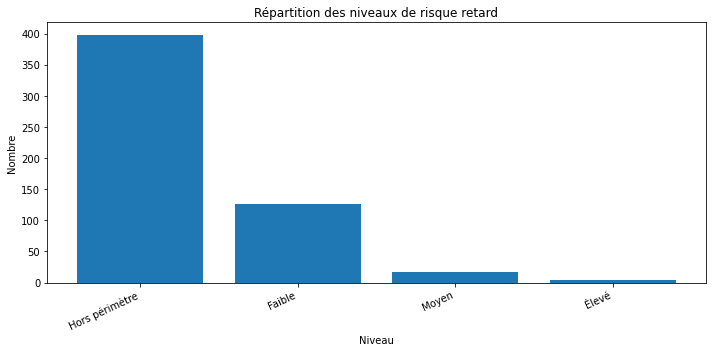

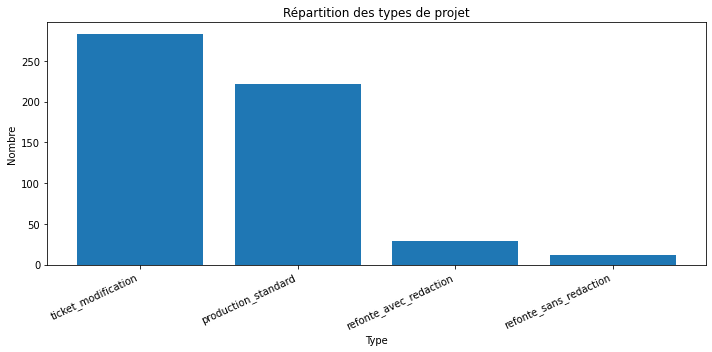

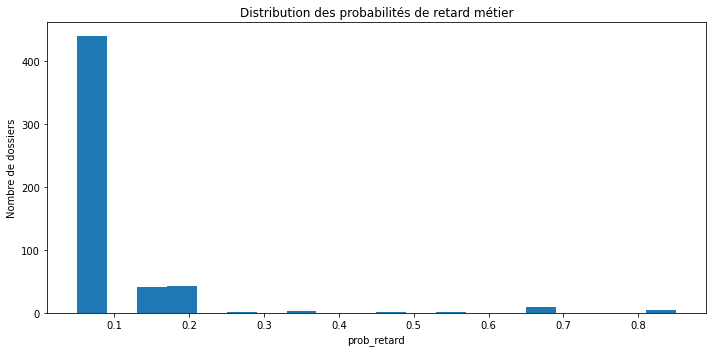

,id_dossier_ml,client_ml,loiHamon_ml,etatR_ml,etatG_ml,jours_restants_livraison,prob_retard,niveau_risque_retard,raison_retard
89,134479,L'ATELIER DE CESAR,1- Production Standard,Validé,Retour CQ traité,1,0.85,Élevé,Rédaction non validée à J+1
109,134422,MLV SALON,1- Production Standard,Validé,En pause,1,0.85,Élevé,Rédaction non validée à J+1
111,134468,SEBASTIEN VALCKE,1- Production Standard,Validé,Finalisé,1,0.85,Élevé,Rédaction non validée à J+1
112,134484,ESSENCE L,1- Production Standard,Validé,En pause,1,0.85,Élevé,Rédaction non validée à J+1
105,134590,PURE AUTO,1- Production Standard,Validé,En pause,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
106,134592,M POSE,1- Production Standard,Validé,En pause,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
107,134622,PACO LOC,1- Production Standard,Validé,En pause,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
118,134593,SERVICES PROPRETÉ CONCEPT,1- Production Standard,Validé,En pause,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
122,134591,GECKO FLEX,1- Production Standard,En cours,En pause,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
127,134632,NOV'AUTO,1- Production Standard,Finalisé,En pause,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant


In [32]:
log("Visualisations métier")

risk_counts = df_model["niveau_risque_retard"].value_counts().reset_index()
risk_counts.columns = ["niveau", "nombre"]
plot_bar(risk_counts, "niveau", "nombre", "Répartition des niveaux de risque retard", "Niveau", "Nombre")

loi_counts = df_model["loi_type"].value_counts().reset_index()
loi_counts.columns = ["type", "nombre"]
plot_bar(loi_counts, "type", "nombre", "Répartition des types de projet", "Type", "Nombre")

plt.figure(figsize=(10, 5))
plt.hist(df_model["prob_retard"].dropna(), bins=20)
plt.title("Distribution des probabilités de retard métier")
plt.xlabel("prob_retard")
plt.ylabel("Nombre de dossiers")
plt.tight_layout()
plt.show()

cols_show = ["id_dossier_ml", "client_ml", "loiHamon_ml", "etatR_ml", "etatG_ml", "jours_restants_livraison", "prob_retard", "niveau_risque_retard", "raison_retard"]
df_model.sort_values(["prob_retard", "jours_restants_livraison"], ascending=[False, True])[cols_show].head(15)

## 11. Modèle ML 1 — Prédiction retard : comparaison de 3 modèles

Objectif : comparer trois modèles qui apprennent à reproduire/valider le raisonnement métier.

Modèles comparés :

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

,modele,accuracy,f1_macro
0,LogisticRegression,0.948905,0.709867
2,GradientBoosting,0.963504,0.665183
1,RandomForest,0.963504,0.644961


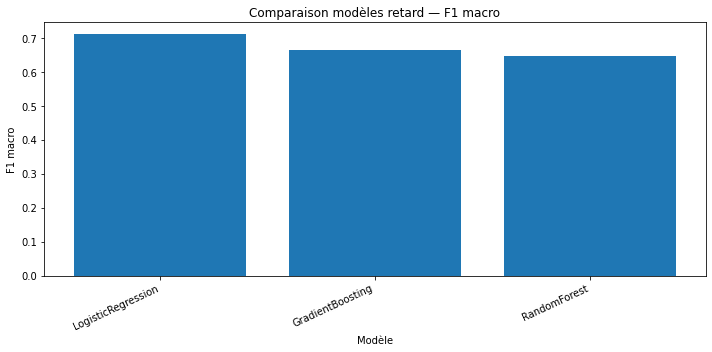

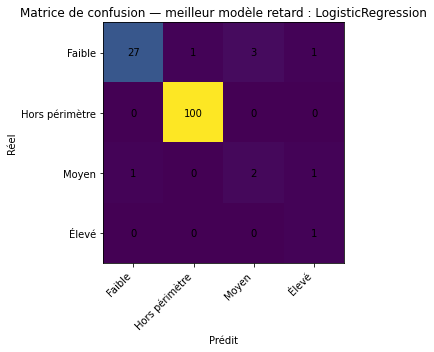

                precision    recall  f1-score   support

        Faible       0.96      0.84      0.90        32
Hors périmètre       0.99      1.00      1.00       100
         Moyen       0.40      0.50      0.44         4
         Élevé       0.33      1.00      0.50         1

      accuracy                           0.95       137
     macro avg       0.67      0.84      0.71       137
  weighted avg       0.96      0.95      0.95       137



In [33]:
retard_features_num = [
    "pages_ml", "estimation_minutes_ml", "dureeR_minutes_ml", "dureeG_minutes_ml",
    "jours_restants_livraison", "required_minutes_redac", "required_minutes_graph",
    "chargeR_restante_minutes", "chargeG_restante_minutes", "charge_totale_restante_minutes",
    "prioriteR_ml", "prioriteG_ml"
]
retard_features_cat = [
    "loi_type", "position_ml", "statut_ml", "etatR_ml", "etatG_ml", "teamR_ml", "teamG_ml", "team_ml"
]

X = df_model[retard_features_num + retard_features_cat].copy()
y = df_model["niveau_risque_retard"].copy()

valid = y.notna() & (y != "")
X = X.loc[valid]
y = y.loc[valid]

if len(y.unique()) < 2 or len(X) < 10:
    print("Pas assez de données/classes pour comparer les modèles retard.")
    retard_compare = pd.DataFrame()
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y if y.value_counts().min() >= 2 else None
    )

    preprocessor = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), retard_features_num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), retard_features_cat),
    ])

    clf_models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, class_weight="balanced"),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

    results = []
    trained_retard_models = {}
    for name, model in clf_models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        results.append({
            "modele": name,
            "accuracy": accuracy_score(y_test, pred),
            "f1_macro": f1_score(y_test, pred, average="macro"),
        })
        trained_retard_models[name] = pipe

    retard_compare = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
    display(retard_compare)
    plot_bar(retard_compare, "modele", "f1_macro", "Comparaison modèles retard — F1 macro", "Modèle", "F1 macro")

    best_retard_name = retard_compare.iloc[0]["modele"]
    best_retard_model = trained_retard_models[best_retard_name]
    best_pred = best_retard_model.predict(X_test)
    labels = sorted(y.unique())
    cm = confusion_matrix(y_test, best_pred, labels=labels)
    plot_confusion(cm, labels, f"Matrice de confusion — meilleur modèle retard : {best_retard_name}")
    print(classification_report(y_test, best_pred))

## 12. Génération CSV Retards

In [34]:
def generate_retards(df_model: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "id_dossier_ml", "code_client_ml", "client_ml", "nature_ml", "loiHamon_ml",
        "position_ml", "statut_ml", "etatR_ml", "etatG_ml", "teamR_ml", "teamG_ml",
        "date_prevue_ml", "date_livraison_ml", "date_operationnelle_ml",
        "jours_restants_livraison", "prob_retard", "niveau_risque_retard", "raison_retard"
    ]
    df = df_model[cols].copy()
    ordre = {"Élevé": 3, "Moyen": 2, "Faible": 1, "Hors périmètre": 0}
    df["ordre_risque"] = df["niveau_risque_retard"].map(ordre).fillna(0)
    df = df.sort_values(["ordre_risque", "prob_retard", "jours_restants_livraison"], ascending=[False, False, True])
    return df.drop(columns=["ordre_risque"])

df_retards = generate_retards(df_model)
df_to_csv(df_retards, OUTPUT_RETARD_RESULTS)
df_retards.head(15)

[OK] fichier généré : c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\prediction_retards_resultats.csv


,id_dossier_ml,code_client_ml,client_ml,nature_ml,loiHamon_ml,position_ml,statut_ml,etatR_ml,etatG_ml,teamR_ml,teamG_ml,date_prevue_ml,date_livraison_ml,date_operationnelle_ml,jours_restants_livraison,prob_retard,niveau_risque_retard,raison_retard
89,134479,510296,L'ATELIER DE CESAR,Site - LocalVisibilité,1- Production Standard,Production,En cours,Validé,Retour CQ traité,Aur@Nex,Genix-Spark 2,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
109,134422,626113,MLV SALON,Site - LocalWeb,1- Production Standard,Production,En cours,Validé,En pause,Vortex-Lab,Genix-Rise 2,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
111,134468,617219,SEBASTIEN VALCKE,Site - LocalAgenda,1- Production Standard,Production,En cours,Validé,Finalisé,Aur@Nex,Genix-Spark 1,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
112,134484,623254,ESSENCE L,Site - LocalVisibilité,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Spark 2,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
105,134590,617651,PURE AUTO,Site - LocalWeb,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Rise 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
106,134592,624259,M POSE,Site - LocalWeb,1- Production Standard,Production,En cours,Validé,En pause,SAViX-Up,Genix-Spark 2,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
107,134622,626394,PACO LOC,Site - LocalVisibilité,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Spark 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
118,134593,620465,SERVICES PROPRETÉ CONCEPT,Site - LocalAgenda,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Spark 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
122,134591,624810,GECKO FLEX,Site - LocalVisibilité,1- Production Standard,Production,En cours,En cours,En pause,Aur@Nex,Genix-Rise 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
127,134632,595172,NOV'AUTO,Site - LocalAuto,1- Production Standard,Production,En cours,Finalisé,En pause,Aur@Nex,Genix-Spark 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant


## 13. Génération charge future / surcharge

In [ ]:
def generate_charge(df_model: pd.DataFrame) -> pd.DataFrame:
    charge_rows = []

    for _, row in df_model.iterrows():
        statut = norm_txt(row.get("statut_ml", ""))
        livraison = norm_txt(row.get("livraison_ml", ""))

        # Seulement les projets en cours, pas les livrés
        if "livre" in statut or "livré" in statut or "termine" in statut:
            continue

        if "livre" in livraison or "livré" in livraison:
            continue

        # Rédaction
        if row["required_minutes_redac"] > 0 and not row["redac_finished"]:
            aff = analyser_affectation_redaction(row)

            if aff is not None:
                charge_rows.append({
                    "id_dossier": row["id_dossier_ml"],
                    "code_client": row["code_client_ml"],
                    "client": row["client_ml"],
                    "loiHamon": row["loiHamon_ml"],
                    "nature": row["nature_ml"],
                    "date_livraison_prevue": row["date_prevue_ml"],
                    "date_livraison_entreprise": row["date_livraison_ml"],
                    "date_operationnelle": row["date_operationnelle_ml"],
                    "jours_restants": row["jours_restants_livraison"],

                    "role": "Rédaction",
                    "collaborateur": aff["employe"],
                    "equipe": aff["team"],
                    "etat": row["etatR_ml"],
                    "etat_affectation": aff["etat_affectation"],
                    "raison_affectation": aff["raison_affectation"],

                    "estimation_minutes_projet": row["estimation_minutes_ml"],
                    "temps_requis_minutes": row["required_minutes_redac"],
                    "duree_deja_faite_minutes": row["dureeR_minutes_ml"],
                    "charge_restante_minutes": row["chargeR_restante_minutes"],
                    "pages": row["pages_ml"],
                    "priorite": row["prioriteR_ml"]
                })

        # Graphisme
        if row["required_minutes_graph"] > 0 and not row["graph_finished"]:
            aff = analyser_affectation_graphisme(row)

            if aff is not None:
                charge_rows.append({
                    "id_dossier": row["id_dossier_ml"],
                    "code_client": row["code_client_ml"],
                    "client": row["client_ml"],
                    "loiHamon": row["loiHamon_ml"],
                    "nature": row["nature_ml"],
                    "date_livraison_prevue": row["date_prevue_ml"],
                    "date_livraison_entreprise": row["date_livraison_ml"],
                    "date_operationnelle": row["date_operationnelle_ml"],
                    "jours_restants": row["jours_restants_livraison"],

                    "role": "Graphisme",
                    "collaborateur": aff["employe"],
                    "equipe": aff["team"],
                    "etat": row["etatG_ml"],
                    "etat_affectation": aff["etat_affectation"],
                    "raison_affectation": aff["raison_affectation"],

                    "estimation_minutes_projet": row["estimation_minutes_ml"],
                    "temps_requis_minutes": row["required_minutes_graph"],
                    "duree_deja_faite_minutes": row["dureeG_minutes_ml"],
                    "charge_restante_minutes": row["chargeG_restante_minutes"],
                    "pages": row["pages_ml"],
                    "priorite": row["prioriteG_ml"]
                })

    df_charge = pd.DataFrame(charge_rows)

    if df_charge.empty:
        return df_charge

    # Nettoyage final : aucune ligne non affectée / CDC / Production
    collab_norm = df_charge["collaborateur"].fillna("").astype(str).map(norm_txt)

    df_charge = df_charge[
        (collab_norm != "")
        & (collab_norm != "non affecte")
        & (collab_norm != "non affecté")
        & (~collab_norm.str.contains("cdc", na=False))
        & (~collab_norm.str.contains("production", na=False))
    ].copy()

    if df_charge.empty:
        return df_charge

    df_charge["capacite_jour_minutes"] = CAPACITE_JOUR_MINUTES
    df_charge["jours_utiles_restants"] = pd.to_numeric(
        df_charge["jours_restants"], errors="coerce"
    ).fillna(1).clip(lower=1)

    # Charge réelle par collaborateur + rôle
    charge_collab = (
        df_charge
        .groupby(["collaborateur", "role"], as_index=False)
        .agg(
            charge_totale_collab_minutes=("charge_restante_minutes", "sum"),
            nb_dossiers_collab=("id_dossier", "count"),
            date_min_operationnelle=("date_operationnelle", "min")
        )
    )

    charge_collab["jours_utiles_collab"] = (
        charge_collab["date_min_operationnelle"] - REFERENCE_DATE
    ).dt.days

    charge_collab["jours_utiles_collab"] = pd.to_numeric(
        charge_collab["jours_utiles_collab"], errors="coerce"
    ).fillna(1).clip(lower=1)

    charge_collab["capacite_disponible_collab_minutes"] = (
        charge_collab["jours_utiles_collab"] * CAPACITE_JOUR_MINUTES
    )

    charge_collab["taux_charge_collab"] = (
        charge_collab["charge_totale_collab_minutes"]
        / charge_collab["capacite_disponible_collab_minutes"]
    ).replace([np.inf, -np.inf], 0).fillna(0)

    def niveau_charge(taux):
        if taux > 0.80:
            return "Élevée"
        if taux > 0.50:
            return "Moyenne"
        return "Faible"

    charge_collab["niveau_charge"] = charge_collab["taux_charge_collab"].apply(niveau_charge)

    df_charge = df_charge.merge(
        charge_collab,
        on=["collaborateur", "role"],
        how="left"
    )

    df_charge["capacite_disponible_minutes"] = (
        df_charge["jours_utiles_restants"] * df_charge["capacite_jour_minutes"]
    )

    df_charge["taux_charge"] = (
        df_charge["charge_restante_minutes"]
        / df_charge["capacite_disponible_minutes"]
    ).replace([np.inf, -np.inf], 0).fillna(0)

    df_charge = df_charge.sort_values(
        ["taux_charge_collab", "date_operationnelle", "charge_restante_minutes"],
        ascending=[False, True, False]
    )

    return df_charge

df_charge = generate_charge(df_model)
df_to_csv(df_charge, OUTPUT_CHARGE_RESULTS)
df_charge.head(15)

[OK] fichier généré : c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\prediction_charge_future.csv


,id_dossier,code_client,client,loiHamon,nature,date_livraison_prevue,date_livraison_entreprise,date_operationnelle,jours_restants,role,...,jours_utiles_restants,capacite_disponible_minutes,taux_charge,charge_totale_collab_minutes,nb_dossiers_collab,date_min_operationnelle,jours_utiles_collab,capacite_disponible_collab_minutes,taux_charge_collab,niveau_charge
712,134787,578408,LA FERME DE L'ARBRE,5- Ticket SEO,Création de page (5H),2026-05-11,NaT,2026-05-11,0,Graphisme,...,1,480,0.250000,120.000000,1,2026-05-11,1,480,0.250000,Faible
617,134878,621496,BISTROT DIX VINS,4- Ticket Modification,Corrections CREA/importantes (1h30 ),2026-05-11,NaT,2026-05-11,0,Graphisme,...,1,480,0.043333,140.800000,2,2026-05-11,1,480,0.293333,Faible
556,135008,615370,LES ATELIERS DE JEANNETTE,4- Ticket Modification,Corrections MAJ/minimes (-15 min),2026-05-12,NaT,2026-05-12,1,Graphisme,...,1,480,0.250000,120.000000,1,2026-05-12,1,480,0.250000,Faible
567,134996,617803,SARL LAMOULIE MAZZARON,4- Ticket Modification,Corrections CREA/importantes (1h ),2026-05-12,NaT,2026-05-12,1,Rédaction,...,1,480,0.250000,120.000000,1,2026-05-12,1,480,0.250000,Faible
586,134938,618138,SAPERLIPOP'S,4- Ticket Modification,Corrections CREA/importantes (2H ),2026-05-12,NaT,2026-05-12,1,Graphisme,...,1,480,0.250000,120.000000,1,2026-05-12,1,480,0.250000,Faible
599,134911,523409,GRAINES DE LIENS,4- Ticket Modification,Corrections MAJ/importantes (1h30 ),2026-05-12,NaT,2026-05-12,1,Graphisme,...,1,480,0.250000,140.800000,2,2026-05-11,1,480,0.293333,Faible
580,135007,609431,KARMADOR TEXIER,4- Ticket Modification,SAV,2026-05-13,NaT,2026-05-13,2,Graphisme,...,2,960,0.375000,360.000000,1,2026-05-13,2,960,0.375000,Faible
139,134586,623725,MABISOL,1- Production Standard,Site - LocalVisibilité,2026-05-15,NaT,2026-05-15,4,Graphisme,...,4,1920,0.375000,720.000000,1,2026-05-15,4,1920,0.375000,Faible
145,134618,622854,LA QUEVRERIE MAJELEAN,1- Production Standard,Site - LocalBoutique Webtool,2026-05-15,NaT,2026-05-15,4,Graphisme,...,4,1920,0.375000,720.000000,1,2026-05-15,4,1920,0.375000,Faible
149,134620,624376,AB DETAILLING AUTO,1- Production Standard,Site - LocalVisibilité,2026-05-15,NaT,2026-05-15,4,Graphisme,...,4,1920,0.375000,720.000000,1,2026-05-15,4,1920,0.375000,Faible


## 14. Modèle ML 2 — Estimation surcharge : comparaison de 3 modèles de régression

Objectif : prédire `charge_restante_minutes` et comparer trois modèles :

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

,modele,MAE,RMSE,R2
2,GradientBoostingRegressor,8.660146,21.377842,0.998076
0,LinearRegression,14.399887,24.230039,0.997528
1,RandomForestRegressor,10.155154,29.422545,0.996355


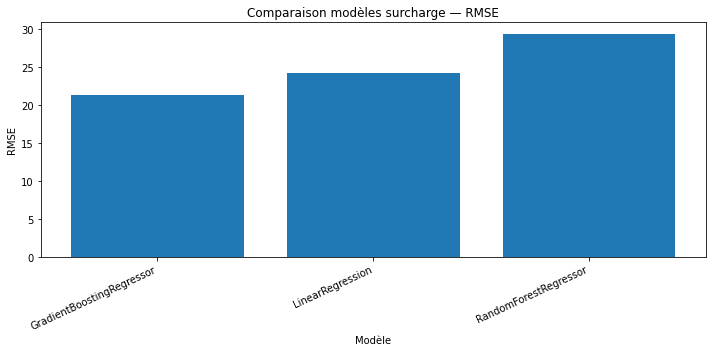

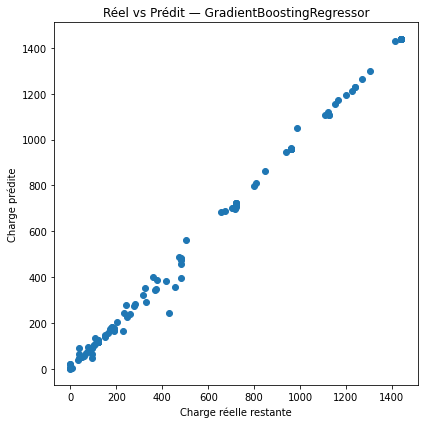

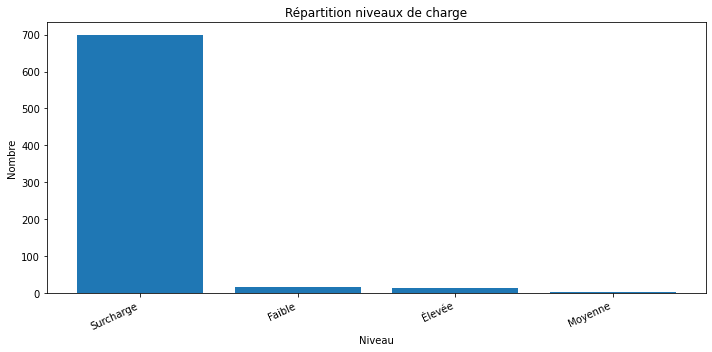

In [36]:
if df_charge.empty or len(df_charge) < 10:
    print("Pas assez de données pour comparer les modèles de surcharge.")
    charge_compare = pd.DataFrame()
else:
    charge_features_num = [
        "jours_restants", "estimation_minutes_projet", "temps_requis_minutes",
        "duree_deja_faite_minutes", "pages", "priorite", "nb_dossiers_collab",
        "charge_totale_collab_minutes", "taux_charge_collab"
    ]
    charge_features_cat = ["role", "collaborateur", "equipe", "etat", "etat_affectation", "loiHamon", "nature"]

    Xc = df_charge[charge_features_num + charge_features_cat].copy()
    yc = df_charge["charge_restante_minutes"].copy()

    X_train, X_test, y_train, y_test = train_test_split(Xc, yc, test_size=0.25, random_state=RANDOM_STATE)

    preproc_reg = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), charge_features_num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), charge_features_cat),
    ])

    reg_models = {
        "LinearRegression": LinearRegression(),
        "RandomForestRegressor": RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE),
        "GradientBoostingRegressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
    }

    reg_results = []
    trained_charge_models = {}
    for name, model in reg_models.items():
        pipe = Pipeline([("prep", preproc_reg), ("model", model)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        rmse = mean_squared_error(y_test, pred, squared=False)
        reg_results.append({
            "modele": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": rmse,
            "R2": r2_score(y_test, pred),
        })
        trained_charge_models[name] = pipe

    charge_compare = pd.DataFrame(reg_results).sort_values("RMSE", ascending=True)
    display(charge_compare)
    plot_bar(charge_compare, "modele", "RMSE", "Comparaison modèles surcharge — RMSE", "Modèle", "RMSE")

    best_charge_name = charge_compare.iloc[0]["modele"]
    best_charge_model = trained_charge_models[best_charge_name]
    pred = best_charge_model.predict(X_test)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, pred)
    plt.title(f"Réel vs Prédit — {best_charge_name}")
    plt.xlabel("Charge réelle restante")
    plt.ylabel("Charge prédite")
    plt.tight_layout()
    plt.show()

niveau_counts = df_charge["niveau_charge"].value_counts().reset_index() if not df_charge.empty else pd.DataFrame()
if not niveau_counts.empty:
    niveau_counts.columns = ["niveau_charge", "nombre"]
    plot_bar(niveau_counts, "niveau_charge", "nombre", "Répartition niveaux de charge", "Niveau", "Nombre")

## 15. Score d'affectation — génération métier

In [37]:
def generate_scores(df_model: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in df_model.iterrows():
        base = {
            "id_dossier": row["id_dossier_ml"],
            "code_client": row["code_client_ml"],
            "client": row["client_ml"],
            "nature": row["nature_ml"],
            "loiHamon": row["loiHamon_ml"],
            "date_livraison_prevue": row["date_prevue_ml"],
            "date_livraison_entreprise": row["date_livraison_ml"],
            "date_operationnelle": row["date_operationnelle_ml"],
            "jours_restants": row["jours_restants_livraison"],
            "etatR": row["etatR_ml"],
            "etatG": row["etatG_ml"],
            "teamR": row["teamR_ml"],
            "teamG": row["teamG_ml"],
            "team_global": row["team_ml"],
            "pages": row["pages_ml"],
        }

        if row["required_minutes_redac"] > 0:
            redac = analyser_affectation_redaction(row)
            rows.append({
                **base,
                **redac,
                "etat": row["etatR_ml"],
                "charge_restante_minutes": row["chargeR_restante_minutes"],
                "duree_deja_faite_minutes": row["dureeR_minutes_ml"],
                "priorite": row["prioriteR_ml"]
            })

        if row["required_minutes_graph"] > 0:
            graph = analyser_affectation_graphisme(row)
            rows.append({
                **base,
                **graph,
                "etat": row["etatG_ml"],
                "charge_restante_minutes": row["chargeG_restante_minutes"],
                "duree_deja_faite_minutes": row["dureeG_minutes_ml"],
                "priorite": row["prioriteG_ml"]
            })

    df_scores = pd.DataFrame(rows)
    if df_scores.empty:
        return df_scores

    charge_collab = df_scores.groupby(["employe", "role"], as_index=False).agg(
        charge_totale_collab=("charge_restante_minutes", "sum"),
        nb_dossiers_collab=("id_dossier", "count")
    )
    df_scores = df_scores.merge(charge_collab, on=["employe", "role"], how="left")

    max_charge = max(float(df_scores["charge_totale_collab"].max() or 1), 1)

    def score_row(row):
        etat_aff = norm_txt(row.get("etat_affectation", ""))
        employe = norm_txt(row.get("employe", ""))
        priorite = float(row.get("priorite", 0) or 0)
        charge_totale = float(row.get("charge_totale_collab", 0) or 0)
        nb_dossiers = float(row.get("nb_dossiers_collab", 0) or 0)
        jours = float(row.get("jours_restants", 999) or 999)

        if "termine" in etat_aff:
            return 100, 100, 100, 100, "Étape déjà terminée"

        if "non affecte" in etat_aff or employe == "" or "non affecte" in employe:
            score_priorite = 100 if priorite >= 4 or jours <= 1 else 60
            return 20, 20, score_priorite, 25, "Non affecté - " + str(row.get("raison_affectation", ""))

        score_charge = 100 * (1 - charge_totale / max_charge)
        score_charge = min(max(score_charge, 0), 100)
        score_disponibilite = 100 - nb_dossiers * 10
        score_disponibilite = min(max(score_disponibilite, 20), 100)

        if priorite >= 4 or jours <= 0:
            score_priorite = 100
        elif priorite >= 2 or jours <= 1:
            score_priorite = 80
        else:
            score_priorite = 60

        score_affectation = 0.40 * score_disponibilite + 0.30 * score_charge + 0.20 * score_priorite + 0.10 * 100

        if score_affectation >= 75:
            avis = "Affectation correcte"
        elif score_affectation >= 50:
            avis = "Affectation à surveiller"
        else:
            avis = "Affectation faible ou surcharge possible"
        avis += " - " + str(row.get("raison_affectation", ""))

        return round(score_charge, 2), round(score_disponibilite, 2), round(score_priorite, 2), round(score_affectation, 2), avis

    scores = df_scores.apply(score_row, axis=1, result_type="expand")
    scores.columns = ["score_charge", "score_disponibilite", "score_priorite", "score_affectation", "avis_affectation"]
    df_scores = pd.concat([df_scores, scores], axis=1)
    return df_scores.sort_values(["id_dossier", "role", "score_affectation"], ascending=[True, True, False])


def generate_top5(df_scores: pd.DataFrame) -> pd.DataFrame:
    if df_scores.empty:
        return df_scores
    return (
        df_scores
        .sort_values(["id_dossier", "role", "score_affectation"], ascending=[True, True, False])
        .groupby(["id_dossier", "role"], as_index=False)
        .head(5)
        .reset_index(drop=True)
    )

df_scores = generate_scores(df_model)
df_top5 = generate_top5(df_scores)
df_to_csv(df_scores, OUTPUT_SCORE_FULL)
df_to_csv(df_top5, OUTPUT_SCORE_TOP5)
df_scores.head(15)

[OK] fichier généré : c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\score_affectation_resultats.csv
[OK] fichier généré : c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\score_affectation_top5.csv


,id_dossier,code_client,client,nature,loiHamon,date_livraison_prevue,date_livraison_entreprise,date_operationnelle,jours_restants,etatR,...,charge_restante_minutes,duree_deja_faite_minutes,priorite,charge_totale_collab,nb_dossiers_collab,score_charge,score_disponibilite,score_priorite,score_affectation,avis_affectation
929,128126,588275,SARL KEVIN DEPOND,Création campagne sur mesure,5- Ticket SEO,2026-01-28,NaT,2026-01-28,-103,,...,120.000000,0.000000,0.0,46218.916667,249,20.00,20.0,100,25.00,Non affecté - Graphisme sans affectation explo...
928,128126,588275,SARL KEVIN DEPOND,Création campagne sur mesure,5- Ticket SEO,2026-01-28,NaT,2026-01-28,-103,,...,120.000000,0.000000,0.0,94889.900000,199,20.00,20.0,100,25.00,Non affecté - Rédaction sans affectation explo...
579,128462,393122,INSTANTS PRECIEUX,Corrections MAJ/importantes (2H30 ),4- Ticket Modification,2026-01-27,2026-01-27,2026-01-27,-104,,...,0.000000,149.250000,4.0,360.000000,18,100.00,100.0,100,100.00,Étape déjà terminée
578,128462,393122,INSTANTS PRECIEUX,Corrections MAJ/importantes (2H30 ),4- Ticket Modification,2026-01-27,2026-01-27,2026-01-27,-104,,...,150.000000,0.000000,0.0,94889.900000,199,20.00,20.0,100,25.00,Non affecté - Rédaction sans affectation explo...
571,128942,584254,L'ORCHIDEE,Corrections MAJ/importantes (1h ),4- Ticket Modification,2026-02-02,2026-02-02,2026-02-02,-98,,...,0.000000,186.566667,4.0,46218.916667,249,20.00,20.0,100,25.00,Non affecté - Graphisme sans affectation explo...
570,128942,584254,L'ORCHIDEE,Corrections MAJ/importantes (1h ),4- Ticket Modification,2026-02-02,2026-02-02,2026-02-02,-98,,...,120.000000,0.000000,0.0,94889.900000,199,20.00,20.0,100,25.00,Non affecté - Rédaction sans affectation explo...
7,129029,598407,AUTOUR DE VOUS,Site - LocalVisibilité,1- Production Standard,2026-02-24,NaT,2026-02-24,-76,Finalisé,...,480.000000,0.000000,-1.0,904.183333,3,99.05,70.0,100,87.71,Affectation correcte - État G affecté/instance...
6,129029,598407,AUTOUR DE VOUS,Site - LocalVisibilité,1- Production Standard,2026-02-24,NaT,2026-02-24,-76,Finalisé,...,862.466667,97.533333,-1.0,94889.900000,199,20.00,20.0,100,25.00,Non affecté - Rédaction sans affectation explo...
573,129034,481638,MD PLOMBERIE CHAUFFAGE,Corrections MAJ/importantes (2H ),4- Ticket Modification,2026-02-04,2026-02-04,2026-02-04,-96,,...,0.000000,266.133333,4.0,46218.916667,249,20.00,20.0,100,25.00,Non affecté - Graphisme sans affectation explo...
572,129034,481638,MD PLOMBERIE CHAUFFAGE,Corrections MAJ/importantes (2H ),4- Ticket Modification,2026-02-04,2026-02-04,2026-02-04,-96,,...,120.000000,0.000000,0.0,94889.900000,199,20.00,20.0,100,25.00,Non affecté - Rédaction sans affectation explo...


## 16. Modèle ML 3 — Affectation : comparaison de 3 modèles de classification

Objectif : apprendre à classer l'état d'affectation : `Affecté`, `Non affecté`, `Terminé`.

Modèles comparés :

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

,modele,accuracy,f1_macro
0,LogisticRegression,1.0,1.0
1,RandomForest,1.0,1.0
2,GradientBoosting,1.0,1.0


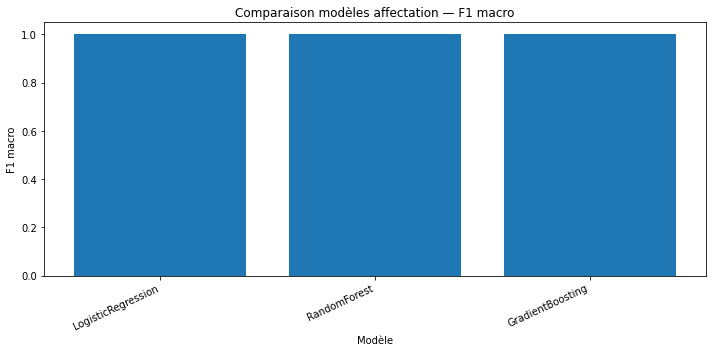

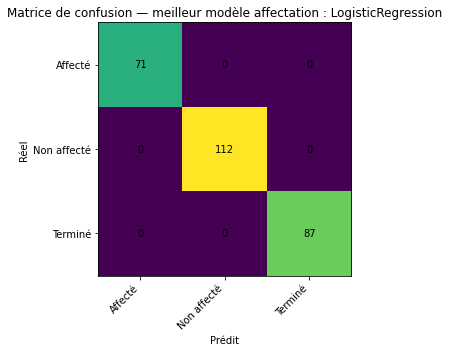

              precision    recall  f1-score   support

     Affecté       1.00      1.00      1.00        71
 Non affecté       1.00      1.00      1.00       112
     Terminé       1.00      1.00      1.00        87

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



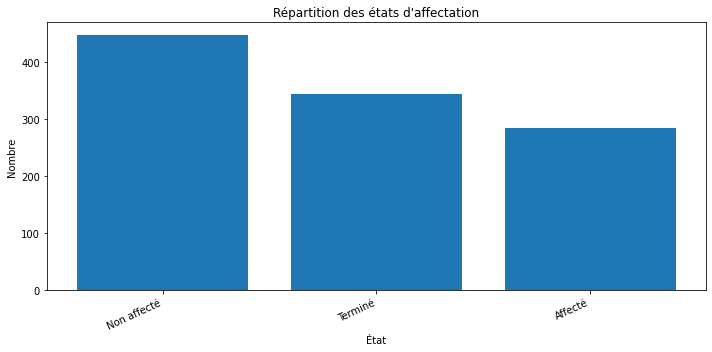

In [38]:
if df_scores.empty or len(df_scores) < 10 or df_scores["etat_affectation"].nunique() < 2:
    print("Pas assez de données/classes pour comparer les modèles d'affectation.")
    aff_compare = pd.DataFrame()
else:
    aff_features_num = ["jours_restants", "pages", "charge_restante_minutes", "duree_deja_faite_minutes", "priorite", "charge_totale_collab", "nb_dossiers_collab"]
    aff_features_cat = ["role", "etat", "team", "teamR", "teamG", "team_global", "loiHamon", "nature"]

    Xa = df_scores[aff_features_num + aff_features_cat].copy()
    ya = df_scores["etat_affectation"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        Xa, ya, test_size=0.25, random_state=RANDOM_STATE, stratify=ya if ya.value_counts().min() >= 2 else None
    )

    preproc_aff = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), aff_features_num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), aff_features_cat),
    ])

    aff_models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, class_weight="balanced"),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

    results = []
    trained_aff_models = {}
    for name, model in aff_models.items():
        pipe = Pipeline([("prep", preproc_aff), ("model", model)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        results.append({
            "modele": name,
            "accuracy": accuracy_score(y_test, pred),
            "f1_macro": f1_score(y_test, pred, average="macro"),
        })
        trained_aff_models[name] = pipe

    aff_compare = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
    display(aff_compare)
    plot_bar(aff_compare, "modele", "f1_macro", "Comparaison modèles affectation — F1 macro", "Modèle", "F1 macro")

    best_aff_name = aff_compare.iloc[0]["modele"]
    best_aff_model = trained_aff_models[best_aff_name]
    pred = best_aff_model.predict(X_test)
    labels = sorted(ya.unique())
    cm = confusion_matrix(y_test, pred, labels=labels)
    plot_confusion(cm, labels, f"Matrice de confusion — meilleur modèle affectation : {best_aff_name}")
    print(classification_report(y_test, pred))

status_counts = df_scores["etat_affectation"].value_counts().reset_index() if not df_scores.empty else pd.DataFrame()
if not status_counts.empty:
    status_counts.columns = ["etat_affectation", "nombre"]
    plot_bar(status_counts, "etat_affectation", "nombre", "Répartition des états d'affectation", "État", "Nombre")

## 17. Visualisation finale claire des résultats opérationnels


Résultats finaux opérationnels
Retards: 545
Charges: 733
Scores: 1078
Top5: 1078

Top 10 risques retard élevés/moyens


,id_dossier_ml,code_client_ml,client_ml,nature_ml,loiHamon_ml,position_ml,statut_ml,etatR_ml,etatG_ml,teamR_ml,teamG_ml,date_prevue_ml,date_livraison_ml,date_operationnelle_ml,jours_restants_livraison,prob_retard,niveau_risque_retard,raison_retard
89,134479,510296,L'ATELIER DE CESAR,Site - LocalVisibilité,1- Production Standard,Production,En cours,Validé,Retour CQ traité,Aur@Nex,Genix-Spark 2,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
109,134422,626113,MLV SALON,Site - LocalWeb,1- Production Standard,Production,En cours,Validé,En pause,Vortex-Lab,Genix-Rise 2,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
111,134468,617219,SEBASTIEN VALCKE,Site - LocalAgenda,1- Production Standard,Production,En cours,Validé,Finalisé,Aur@Nex,Genix-Spark 1,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
112,134484,623254,ESSENCE L,Site - LocalVisibilité,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Spark 2,2026-05-12,NaT,2026-05-12,1,0.85,Élevé,Rédaction non validée à J+1
105,134590,617651,PURE AUTO,Site - LocalWeb,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Rise 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
106,134592,624259,M POSE,Site - LocalWeb,1- Production Standard,Production,En cours,Validé,En pause,SAViX-Up,Genix-Spark 2,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
107,134622,626394,PACO LOC,Site - LocalVisibilité,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Spark 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
118,134593,620465,SERVICES PROPRETÉ CONCEPT,Site - LocalAgenda,1- Production Standard,Production,En cours,Validé,En pause,Aur@Nex,Genix-Spark 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
122,134591,624810,GECKO FLEX,Site - LocalVisibilité,1- Production Standard,Production,En cours,En cours,En pause,Aur@Nex,Genix-Rise 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant
127,134632,595172,NOV'AUTO,Site - LocalAuto,1- Production Standard,Production,En cours,Finalisé,En pause,Aur@Nex,Genix-Spark 1,2026-05-15,NaT,2026-05-15,4,0.65,Moyen,Dossier avec état bloquant malgré délai restant



Top 10 charges restantes


,id_dossier,code_client,client,loiHamon,nature,date_livraison_prevue,date_livraison_entreprise,date_operationnelle,jours_restants,role,...,jours_utiles_restants,capacite_disponible_minutes,taux_charge,charge_totale_collab_minutes,nb_dossiers_collab,date_min_operationnelle,jours_utiles_collab,capacite_disponible_collab_minutes,taux_charge_collab,niveau_charge
208,134697,624101,ADDITEK,1- Production Standard,Site - LocalVisibilité,2026-05-18,NaT,2026-05-18,7,Rédaction,...,7,3360,0.571429,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge
300,134957,618938,LEREAU LOCATION TP,1- Production Standard,Site - LocalAudience,2026-05-20,NaT,2026-05-20,9,Rédaction,...,9,4320,0.444444,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge
351,134987,619282,STORES SOLUTIONS LEMAN,2- Refonte Avec Rédaction,Corrections CREA refonte,2026-05-21,NaT,2026-05-21,10,Rédaction,...,10,4800,0.300000,5391.283333,6,2026-05-13,2,960,5.61592,Surcharge
228,134754,626830,LE REPIT DES MAUX,1- Production Standard,Site - LocalVisibilité,2026-05-18,NaT,2026-05-18,7,Rédaction,...,7,3360,0.428571,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge
268,134847,618613,LE RELAIS DE LISSAC,1- Production Standard,Site - LocalVisibilité,2026-05-19,NaT,2026-05-19,8,Rédaction,...,8,3840,0.375000,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge
270,134849,618479,CAT'CHAPA,1- Production Standard,Site - LocalBoutique Webtool,2026-05-19,NaT,2026-05-19,8,Rédaction,...,8,3840,0.375000,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge
372,134818,239843,EVELYNE NOUGÉ,2- Refonte Avec Rédaction,Corrections MAJ refonte,2026-05-19,NaT,2026-05-19,8,Rédaction,...,8,3840,0.375000,5391.283333,6,2026-05-13,2,960,5.61592,Surcharge
276,134883,622777,ESPRIT CREATIF,1- Production Standard,Site - LocalWeb,2026-05-20,NaT,2026-05-20,9,Rédaction,...,9,4320,0.333333,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge
280,134929,617220,VICHY VTC,1- Production Standard,Site - LocalVisibilité,2026-05-20,NaT,2026-05-20,9,Rédaction,...,9,4320,0.333333,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge
226,134752,625706,SOL PAYSAGE,1- Production Standard,Site - LocalWeb,2026-05-18,NaT,2026-05-18,7,Rédaction,...,7,3360,0.428571,88320.000000,66,2026-05-15,4,1920,46.00000,Surcharge



Top 10 affectations à surveiller


,id_dossier,code_client,client,nature,loiHamon,date_livraison_prevue,date_livraison_entreprise,date_operationnelle,jours_restants,etatR,...,charge_restante_minutes,duree_deja_faite_minutes,priorite,charge_totale_collab,nb_dossiers_collab,score_charge,score_disponibilite,score_priorite,score_affectation,avis_affectation
929,128126,588275,SARL KEVIN DEPOND,Création campagne sur mesure,5- Ticket SEO,2026-01-28,NaT,2026-01-28,-103,,...,120.000000,0.000000,0.0,46218.916667,249,20.0,20.0,100,25.0,Non affecté - Graphisme sans affectation explo...
653,134775,487984,ND CONCEPT TRAVAUX,Corrections MAJ/importantes (1h ),4- Ticket Modification,2026-05-07,2026-05-07,2026-05-07,-4,Validé,...,49.233333,70.766667,4.0,46218.916667,249,20.0,20.0,100,25.0,Non affecté - Graphisme sans affectation explo...
726,134777,566322,ETS STEVE,Corrections MAJ/importantes (2H ),4- Ticket Modification,2026-05-11,NaT,2026-05-11,0,,...,120.000000,0.000000,0.0,94889.900000,199,20.0,20.0,60,25.0,Non affecté - Rédaction sans affectation explo...
878,134781,218814,PROVOC,Corrections MAJ/importantes (2H30 ),4- Ticket Modification,2026-05-12,NaT,2026-05-12,1,En pause,...,69.866667,80.133333,-1.0,94889.900000,199,20.0,20.0,100,25.0,Non affecté - Rédaction sans affectation explo...
655,134782,607164,ELECTRONIC DISCOVERY,Corrections MAJ/minimes (-15 min),4- Ticket Modification,2026-05-07,2026-05-07,2026-05-07,-4,Validé,...,111.250000,8.750000,-1.0,46218.916667,249,20.0,20.0,100,25.0,Non affecté - Graphisme sans affectation explo...
549,134784,432145,MASSAGES AMMA ASSIS,Corrections MAJ/minimes (-30 min),4- Ticket Modification,2026-05-07,2026-05-07,2026-05-07,-4,,...,60.216667,59.783333,-1.0,46218.916667,249,20.0,20.0,100,25.0,Non affecté - Graphisme sans affectation explo...
548,134784,432145,MASSAGES AMMA ASSIS,Corrections MAJ/minimes (-30 min),4- Ticket Modification,2026-05-07,2026-05-07,2026-05-07,-4,,...,120.000000,0.000000,0.0,94889.900000,199,20.0,20.0,100,25.0,Non affecté - Rédaction sans affectation explo...
1031,134788,184985,CONCIERGERIE MANOUCHKA DATCHA,Référencement/SEO (30 min),5- Ticket SEO,2026-05-11,NaT,2026-05-11,0,Affecté,...,120.000000,0.000000,0.0,46218.916667,249,20.0,20.0,60,25.0,Non affecté - Graphisme sans affectation explo...
546,134773,476965,BECKER RESINE 67,Corrections MAJ/minimes (-30 min),4- Ticket Modification,2026-05-07,2026-05-07,2026-05-07,-4,,...,120.000000,0.000000,0.0,94889.900000,199,20.0,20.0,100,25.0,Non affecté - Rédaction sans affectation explo...
728,134789,616880,BJCLIMATEC,Corrections CREA/importantes (1h30 ),4- Ticket Modification,2026-05-11,NaT,2026-05-11,0,,...,120.000000,0.000000,0.0,94889.900000,199,20.0,20.0,60,25.0,Non affecté - Rédaction sans affectation explo...


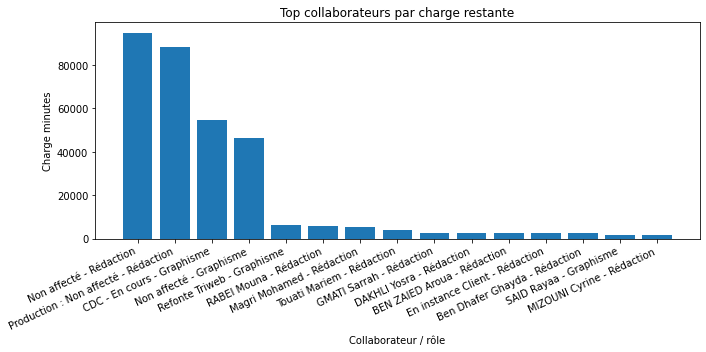

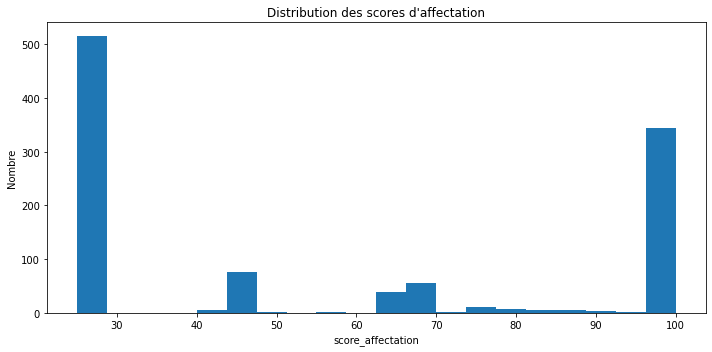

In [39]:
log("Résultats finaux opérationnels")

print("Retards:", len(df_retards))
print("Charges:", len(df_charge))
print("Scores:", len(df_scores))
print("Top5:", len(df_top5))

print("\nTop 10 risques retard élevés/moyens")
display(df_retards[df_retards["niveau_risque_retard"].isin(["Élevé", "Moyen"])].head(10))

print("\nTop 10 charges restantes")
if not df_charge.empty:
    display(df_charge.sort_values("charge_restante_minutes", ascending=False).head(10))

print("\nTop 10 affectations à surveiller")
if not df_scores.empty:
    display(df_scores.sort_values("score_affectation", ascending=True).head(10))

if not df_charge.empty:
    top_collab = (
        df_charge.groupby(["collaborateur", "role"], as_index=False)
        .agg(charge_totale=("charge_restante_minutes", "sum"), nb_dossiers=("id_dossier", "count"))
        .sort_values("charge_totale", ascending=False)
        .head(15)
    )
    top_collab["collab_role"] = top_collab["collaborateur"].astype(str) + " - " + top_collab["role"].astype(str)
    plot_bar(top_collab, "collab_role", "charge_totale", "Top collaborateurs par charge restante", "Collaborateur / rôle", "Charge minutes")

if not df_scores.empty:
    plt.figure(figsize=(10, 5))
    plt.hist(df_scores["score_affectation"].dropna(), bins=20)
    plt.title("Distribution des scores d'affectation")
    plt.xlabel("score_affectation")
    plt.ylabel("Nombre")
    plt.tight_layout()
    plt.show()

## 18. Résumé fichiers générés

In [40]:
files = [
    OUTPUT_RAW,
    OUTPUT_CLEAN,
    OUTPUT_RETARD_RESULTS,
    OUTPUT_CHARGE_RESULTS,
    OUTPUT_SCORE_FULL,
    OUTPUT_SCORE_TOP5,
]

for file in files:
    print(file, "OK" if file.exists() else "MANQUANT")

print("\nTu peux maintenant relancer FastAPI et tester :")
print("http://localhost:8000/models/retards")
print("http://localhost:8000/models/charge")
print("http://localhost:8000/models/score-affectation")

c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\triweb_raw_api.csv OK
c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\triweb_clean_ml_dataset.csv OK
c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\prediction_retards_resultats.csv OK
c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\prediction_charge_future.csv OK
c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\score_affectation_resultats.csv OK
c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\score_affectation_top5.csv OK

Tu peux maintenant relancer FastAPI et tester :
http://localhost:8000/models/retards
http://localhost:8000/models/charge
http://localhost:8000/models/score-affectation
